# Ouvidoria do Distrito Federal (OUV-DF): o que o cidadão demanda e o que o governo resolve?

**Projeto Final — Introdução à Ciência de Dados (CEUB)** · Prof. MsC Pedro H. Mello

**Integrantes:** Lucca Mariz · Vitor Pupe · Lucas Cerqueira

---

## Pergunta de pesquisa

> **O que a população do Distrito Federal mais demanda da Ouvidoria-Geral (OUV-DF) entre 2016 e 2025, quem se manifesta e qual é o desfecho dessas manifestações?**

Desdobramentos:
- Que **tipos** de manifestação predominam (reclamação, solicitação, denúncia, elogio…)?
- Em quais **temas e assuntos** as demandas se concentram?
- Como o **volume** evoluiu no tempo?
- Qual o **perfil** de quem se manifesta (idade, sexo, região administrativa)?
- O poder público **resolve** o que é demandado?

## Fonte dos dados

**Portal de Dados Abertos do Governo do DF** — conjunto *“Dados Estatísticos do Sistema de Ouvidoria / OUV-DF”* (licença de dados abertos).
Link: https://www.dados.df.gov.br/dataset/dados-abertos-do-sistema-de-ouvidoria-ouv-df

A tabela central é `TB_MANIFESTACAO` (uma linha por manifestação), acompanhada de tabelas de domínio (Tema, Assunto, Classificação, Situação, Sexo, Região Administrativa). Os códigos (`*_id`) são decodificados via essas tabelas. Os arquivos originais estão em **ISO‑8859‑1**, separador `;`; a tabela de manifestações é versionada compactada (`manifestacao.csv.gz`).

## Organização do trabalho (4 etapas)

1. **Entendimento e descrição** dos dados
2. **Completude e limpeza** (nulos, duplicatas, valores estranhos, tipagem)
3. **Análise e visualização** (8 gráficos, cada um interpretado)
4. **Conclusões**

## 0. Configuração do ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
PALETA = sns.color_palette("crest", 10)
AZUL = "#2a6f97"; LARANJA = "#e8702a"; VERDE = "#2a9d8f"; VERMELHO = "#c1121f"

# Localiza a pasta data/ subindo diretórios (roda da raiz OU de dentro de notebook/)
def achar_pasta(nome):
    p = Path.cwd()
    for _ in range(6):
        if (p / nome).is_dir():
            return p / nome
    p2 = p
    for _ in range(6):
        if (p2 / nome).is_dir():
            return p2 / nome
        p2 = p2.parent
    raise FileNotFoundError(f"pasta {nome}/ não encontrada a partir de {Path.cwd()}")

DATA = achar_pasta("data")
RAIZ = DATA.parent
FIG = RAIZ / "apresentacao" / "figuras"
FIG.mkdir(parents=True, exist_ok=True)
print("data/   ->", DATA)
print("figuras ->", FIG)

def salvar(fig, nome):
    "Salva a figura em apresentacao/figuras/ para reuso nos slides."
    fig.savefig(FIG / nome, dpi=130, bbox_inches="tight", facecolor="white")

data/   -> C:\Users\lucca\DOCUMENTOS E PROJETOS\PROJETOS\Faculdade\introdução a Ciencia de dados\data
figuras -> C:\Users\lucca\DOCUMENTOS E PROJETOS\PROJETOS\Faculdade\introdução a Ciencia de dados\apresentacao\figuras


---
# 1. Entendimento e descrição dos dados

Carregamos a tabela de manifestações e as tabelas de domínio. Lemos tudo como texto
(`dtype=str`) para evitar inferências erradas (ex.: códigos com zero à esquerda) e
convertemos os tipos de forma controlada na etapa de limpeza.

In [2]:
df = pd.read_csv(DATA / "manifestacao.csv.gz", sep=";", encoding="latin-1", dtype=str)
df.columns = [c.strip() for c in df.columns]

def ler_dim(nome):
    d = pd.read_csv(DATA / nome, sep=";", encoding="latin-1", dtype=str)
    d.columns = [c.strip() for c in d.columns]
    return d

dim_tema   = ler_dim("dim_tema.csv")
dim_assunto= ler_dim("dim_assunto.csv")
dim_class  = ler_dim("dim_classificacao.csv")
dim_sit    = ler_dim("dim_situacao.csv")
dim_sexo   = ler_dim("dim_sexo.csv")
dim_ra     = ler_dim("dim_regiao_administrativa.csv")

print("Manifestações:", df.shape[0], "linhas x", df.shape[1], "colunas")

Manifestações: 2153285 linhas x 17 colunas


### Amostra das primeiras linhas

In [3]:
df.head()

,Id,Ano Abertura,Número de Protocolo,Assunto_id,IDADE,Sexo_id,Bairro,LocalDoFato_id,Classificacao_id,LocalizacaoAtual_id,Data Abertura,Situacao_id,Identificada,Anonima (S) Sim (N) Não,RegiaoAdministrativa_id,Vinculada (S) Sim (N) Não,TipoEntrada_id
0,18836,2016,18352,528,53,2,Samambaia Norte (Samambaia),18863,2,01086,Oct 18 2016 6:00PM,3,1,N,1,N,01002
1,18837,2016,18353,156,NaN,NaN,NaN,18864,2,01040,Oct 18 2016 6:02PM,3,0,S,12,N,01002
2,18842,2016,18358,488,45,1,Sul (Águas Claras),18869,3,01009002,Oct 18 2016 6:09PM,4,1,N,20,N,04001
3,18843,2016,18359,149,NaN,NaN,NaN,18870,1,01040,Oct 18 2016 6:14PM,3,0,S,11,N,01002
4,18844,2016,18360,536,NaN,NaN,NaN,18871,1,01078004,Oct 18 2016 6:14PM,3,0,S,5,N,04001


### Tipos e estrutura de cada coluna

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2153285 entries, 0 to 2153284
Data columns (total 17 columns):
 #   Column                     Dtype
---  ------                     -----
 0   Id                         str  
 1   Ano Abertura               str  
 2   Número de Protocolo        str  
 3   Assunto_id                 str  
 4   IDADE                      str  
 5   Sexo_id                    str  
 6   Bairro                     str  
 7   LocalDoFato_id             str  
 8   Classificacao_id           str  
 9   LocalizacaoAtual_id        str  
 10  Data Abertura              str  
 11  Situacao_id                str  
 12  Identificada               str  
 13  Anonima (S) Sim (N) Não    str  
 14  RegiaoAdministrativa_id    str  
 15  Vinculada (S) Sim (N) Não  str  
 16  TipoEntrada_id             str  
dtypes: str(17)
memory usage: 279.3 MB


### O que é cada coluna

| Coluna | Descrição |
|---|---|
| `Id` | Identificador único da manifestação |
| `Ano Abertura` | Ano de abertura da manifestação |
| `Número de Protocolo` | Número de protocolo no sistema |
| `Assunto_id` | Código do **assunto** (liga à tabela de Assunto, que aponta para o Tema) |
| `IDADE` | Idade declarada do manifestante |
| `Sexo_id` | Código do **sexo** (1 Masculino, 2 Feminino, 3 Outros) |
| `Bairro` | Bairro informado |
| `LocalDoFato_id` | Código do local do fato |
| `Classificacao_id` | **Tipo** da manifestação (Denúncia, Reclamação, Solicitação, Sugestão, Informação, Elogio) |
| `LocalizacaoAtual_id` | Código da localização atual na tramitação |
| `Data Abertura` | Data e hora de abertura |
| `Situacao_id` | **Situação/desfecho** (Recebida, Respondida, Resolvida, Não Resolvida…) |
| `Identificada` | Manifestação identificada (1) ou não (0) |
| `Anonima (S) Sim (N) Não` | Manifestação anônima (S/N) |
| `RegiaoAdministrativa_id` | **Região Administrativa** do DF |
| `Vinculada (S) Sim (N) Não` | Vinculada a outra manifestação (S/N) |
| `TipoEntrada_id` | Canal de entrada da manifestação |

**Tabelas de domínio** carregadas para traduzir os códigos:

In [5]:
print("TEMAS (", len(dim_tema), "):", ", ".join(dim_tema["Descricao"].head(14)))
print()
print("CLASSIFICAÇÃO:", ", ".join(dim_class["Descricao"]))
print()
print("SITUAÇÃO:", ", ".join(dim_sit["Descricao"]))
print()
print("REGIÕES ADMINISTRATIVAS:", len(dim_ra))

TEMAS ( 14 ): Agricultura e Abastecimento, Cultura, Desenvolvimento Social, Educação, Ciência e Tecnologia, Esporte e Lazer, Finanças, Habitação, Urbanismo e Meio Ambiente, Justiça, Segurança e Cidadania, Saneamento e Energia, Saúde, Trabalho e Empreendedorismo, Transporte e Mobilidade, Administração Pública, Zeladoria

CLASSIFICAÇÃO: Denúncia, Reclamação, Solicitação, Sugestão, Informação, Elogio, Valor utilizado quando a robô IZA estiver indisponível

SITUAÇÃO: Recebida, Em Análise, Respondida, Não Resolvida, Resolvida, Vencida, Prorrogada, Inválida, Vencida após prorrogação, Não resolvida após resposta complementar, Resolvida após resposta complementar

REGIÕES ADMINISTRATIVAS: 35


### Estatísticas básicas das variáveis numéricas

As únicas variáveis genuinamente numéricas são `IDADE` e `Ano Abertura`.
Os demais campos são categóricos (códigos) ou texto. Abaixo, média, mediana, moda,
mínimo e máximo da **idade** (antes da limpeza — note os valores impossíveis).

In [6]:
idade_bruta = pd.to_numeric(df["IDADE"], errors="coerce")
ano = pd.to_numeric(df["Ano Abertura"], errors="coerce")

resumo = pd.DataFrame({
    "IDADE (bruta)": [idade_bruta.mean(), idade_bruta.median(), idade_bruta.mode().iloc[0],
                      idade_bruta.min(), idade_bruta.max(), idade_bruta.count()],
    "ANO Abertura":  [ano.mean(), ano.median(), ano.mode().iloc[0],
                      ano.min(), ano.max(), ano.count()],
}, index=["média","mediana","moda","mínimo","máximo","n (não nulos)"]).round(1)
resumo

,IDADE (bruta),ANO Abertura
média,46.3,2020.9
mediana,45.0,2021.0
moda,46.0,2024.0
mínimo,-7967.0,2016.0
máximo,266.0,2025.0
n (não nulos),1544829.0,2153285.0


> ⚠️ A idade bruta tem **mínimo negativo** e **máximo acima de 200** — valores impossíveis que
> serão tratados na próxima etapa. O período de abertura vai de **2016 a 2025**.

---
# 2. Completude e limpeza

Verificamos nulos, duplicatas e valores impossíveis, e corrigimos a tipagem — justificando cada decisão.

### 2.1 Valores ausentes por coluna

In [7]:
# Strings vazias contam como ausentes -> converte "" em NaN
df = df.replace(r"^\s*$", np.nan, regex=True)

nulos = df.isna().sum()
tab_nulos = pd.DataFrame({
    "nulos": nulos,
    "% nulos": (nulos / len(df) * 100).round(1)
}).sort_values("% nulos", ascending=False)
tab_nulos

,nulos,% nulos
LocalDoFato_id,677358,31.5
RegiaoAdministrativa_id,677358,31.5
IDADE,608456,28.3
Sexo_id,602082,28.0
Bairro,554865,25.8
Id,0,0.0
Assunto_id,0,0.0
Ano Abertura,0,0.0
Número de Protocolo,0,0.0
Classificacao_id,0,0.0


**Leitura:** os campos obrigatórios do sistema (Id, datas, classificação, situação, anônima)
**não têm nulos**. O preenchimento opcional pelo cidadão concentra as faltas:
`RegiaoAdministrativa`/`LocalDoFato` (~31%), `IDADE` (~28%), `Sexo` (~28%) e `Bairro` (~26%).

**Decisão:** como esses campos faltam em ~1/4 a 1/3 dos registros, **não removemos as linhas**
(perderíamos ~600 mil manifestações e enviesaríamos a análise). Em vez disso, **mantemos os nulos
e filtramos coluna a coluna** em cada gráfico que depende do campo — deixando claro o tamanho da
base usada em cada caso.

### 2.2 Duplicatas

In [8]:
dup_exatas = df.duplicated().sum()
dup_id = df["Id"].duplicated().sum()
print("Linhas idênticas:", dup_exatas, "| Ids repetidos:", dup_id)
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removidas {antes - len(df)} duplicata(s). Linhas restantes: {len(df)}")

Linhas idênticas: 1 | Ids repetidos: 1


Removidas 1 duplicata(s). Linhas restantes: 2153284


**Decisão:** removemos a duplicata exata — registro idêntico não agrega informação.

### 2.3 Correção de tipos e de valores impossíveis

In [9]:
# (a) Data de abertura -> datetime. Formato SQL Server: "Oct 18 2016  6:00PM"
df["DataAbertura"] = pd.to_datetime(
    df["Data Abertura"].str.replace(r"\s+", " ", regex=True).str.strip(),
    format="%b %d %Y %I:%M%p", errors="coerce")

# (b) Ano -> inteiro
df["Ano"] = pd.to_numeric(df["Ano Abertura"], errors="coerce").astype("Int64")

# (c) Idade -> numérica; idades fora de [1, 110] viram NaN (impossíveis/erro de digitação)
idade = pd.to_numeric(df["IDADE"], errors="coerce")
impossiveis = int(((idade < 1) | (idade > 110)).sum())
df["Idade"] = idade.where(idade.between(1, 110))
print("Datas convertidas sem falha:", df["DataAbertura"].notna().all())
print("Idades impossíveis zeradas (viraram NaN):", impossiveis)
print("Período:", df["DataAbertura"].min(), "->", df["DataAbertura"].max())

Datas convertidas sem falha: True
Idades impossíveis zeradas (viraram NaN): 391
Período: 2016-07-16 14:27:00 -> 2025-02-02 23:40:00


**Decisões:**
- `Data Abertura` estava em texto no formato do SQL Server → convertida para `datetime` (100% sem falha).
- `Ano` → inteiro.
- `IDADE` tinha valores impossíveis (negativos e acima de 110, incluindo −7967 e 266). Tratamos como
  erro de digitação e os zeramos (viram nulo) em vez de descartar a linha inteira.

### 2.4 Decodificação dos códigos (join com as tabelas de domínio)

In [10]:
def mapa(dim): return dict(zip(dim["Id"].astype(str), dim["Descricao"]))

df["Classificacao"] = df["Classificacao_id"].astype(str).map(mapa(dim_class))
df["Situacao"]      = df["Situacao_id"].astype(str).map(mapa(dim_sit))
df["Sexo"]          = df["Sexo_id"].astype(str).map(mapa(dim_sexo))
df["RA"]            = df["RegiaoAdministrativa_id"].astype(str).map(mapa(dim_ra))

# Tema vem do Assunto: Assunto_id -> Tema_id -> Descrição do Tema
assunto_para_tema = dict(zip(dim_assunto["Id"].astype(str), dim_assunto["Tema_id"].astype(str)))
df["Tema"] = df["Assunto_id"].astype(str).map(assunto_para_tema).map(mapa(dim_tema))
df["Assunto"] = df["Assunto_id"].astype(str).map(mapa(dim_assunto))

# Remove a categoria de ruído da robô IZA (placeholder técnico, ~0%)
df.loc[df["Classificacao"].str.contains("IZA", na=False), "Classificacao"] = np.nan

df[["Classificacao","Tema","Situacao","Sexo","RA"]].head()

,Classificacao,Tema,Situacao,Sexo,RA
0,Reclamação,Transporte e Mobilidade,Respondida,Feminino,RA-PP (Plano Piloto)
1,Reclamação,"Habitação, Urbanismo e Meio Ambiente",Respondida,NaN,RA SAM (Samambaia)
2,Solicitação,Transporte e Mobilidade,Não Resolvida,Masculino,RA AC (Águas Claras)
3,Denúncia,Administração Pública,Respondida,NaN,RA CRUZ (Cruzeiro)
4,Denúncia,Transporte e Mobilidade,Respondida,NaN,RA-SOBR (Sobradinho)


**Resultado da limpeza:** base com **≈ 2,15 milhões de manifestações**, datas e idade tipadas, e colunas
legíveis (`Classificacao`, `Tema`, `Situacao`, `Sexo`, `RA`) prontas para a análise.

### 2.5 Perfil geral do manifestante (estatísticas de apoio)

In [11]:
sexo_pct = (df["Sexo"].fillna("Não informado").value_counts(normalize=True) * 100).round(1)
print("Distribuição por sexo (%):")
print(sexo_pct.to_string())
print(f"\nIdade — média: {df['Idade'].mean():.1f} | mediana: {df['Idade'].median():.0f} anos"
      f" | base válida: {df['Idade'].notna().sum():,}")
print(f"Manifestações anônimas: {(df['Anonima (S) Sim (N) Não'] == 'S').mean()*100:.1f}%")

Distribuição por sexo (%):
Sexo
Feminino         41.6
Masculino        30.3
Não informado    28.0
Outros            0.1

Idade — média: 46.5 | mediana: 45 anos | base válida: 1,544,437


Manifestações anônimas: 18.1%


**Leitura:** entre quem informa o sexo, **mulheres são maioria** (~42% vs ~30% de homens; ~28% não
informam). A idade mediana é de **45 anos** e apenas ~18% das manifestações são anônimas — ou seja, o
cidadão em geral se identifica ao acionar a Ouvidoria. Essas estatísticas embasam a Conclusão 4.

---
# 3. Análise e visualização

Oito gráficos de tipos variados (barra, barra horizontal, linha, histograma, boxplot e dispersão),
cada um seguido de sua interpretação.

### Gráfico 1 — Tipos de manifestação (classificação)

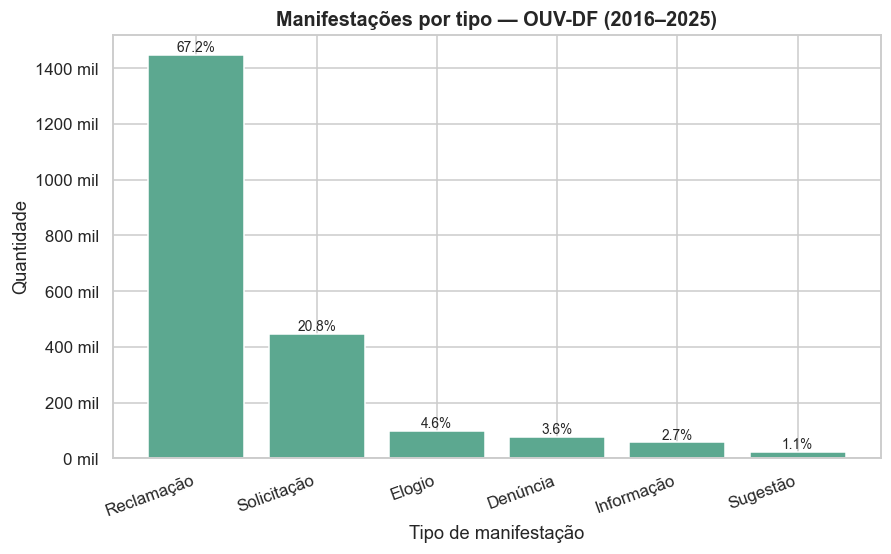

In [12]:
cls = df["Classificacao"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(cls.index, cls.values, color=PALETA[2])
ax.set_title("Manifestações por tipo — OUV-DF (2016–2025)")
ax.set_xlabel("Tipo de manifestação"); ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} mil"))
plt.xticks(rotation=20, ha="right")
total = cls.sum()
for b, v in zip(barras, cls.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v/total*100:.1f}%", ha="center", va="bottom", fontsize=9)
salvar(fig, "fig01_classificacao.png"); plt.show()

**Interpretação:** a Ouvidoria é, antes de tudo, um **canal de reclamação**: ~**67%** de todas as
manifestações são reclamações. Solicitações vêm em seguida (~21%). Manifestações positivas (elogios)
são apenas ~5%, e denúncias ~4%. Ou seja, o cidadão procura a OUV-DF sobretudo para **cobrar** a
qualidade de serviços públicos, não para elogiar.

### Gráfico 2 — Temas mais demandados

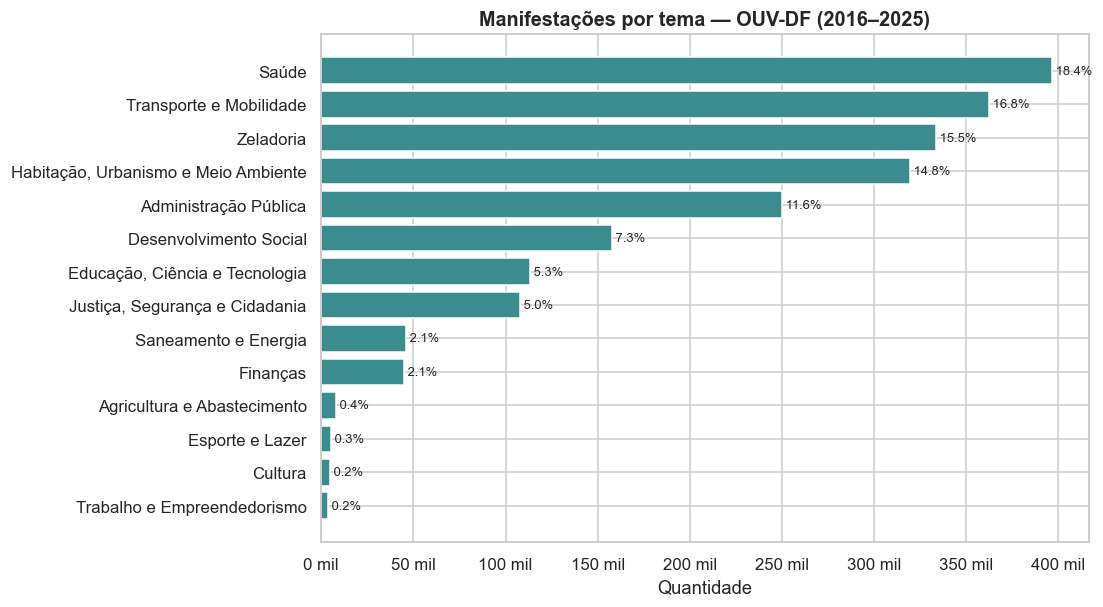

In [13]:
tem = df["Tema"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(tem.index, tem.values, color=PALETA[4])
ax.set_title("Manifestações por tema — OUV-DF (2016–2025)")
ax.set_xlabel("Quantidade"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} mil"))
tot = tem.sum()
for i, v in enumerate(tem.values):
    ax.text(v, i, f" {v/tot*100:.1f}%", va="center", fontsize=8.5)
salvar(fig, "fig02_temas.png"); plt.show()

**Interpretação:** as demandas se concentram em **serviços essenciais e urbanos**. **Saúde** (~18%),
**Transporte e Mobilidade** (~17%), **Zeladoria** (~15%) e **Habitação/Urbanismo/Meio Ambiente** (~15%)
somam **cerca de 65%** de tudo. Temas como Cultura, Esporte e Trabalho ficam abaixo de 1% cada — o
sistema é movido pelo cotidiano do morador (consulta médica, ônibus, buraco na via, iluminação).

### Gráfico 3 — Evolução do volume no tempo

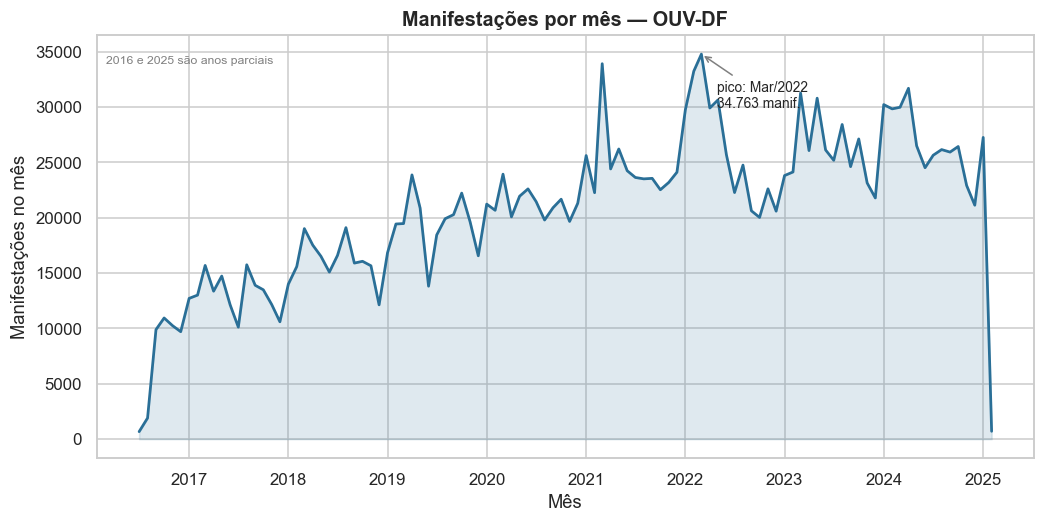

In [14]:
mensal = df.dropna(subset=["DataAbertura"]).groupby(df["DataAbertura"].dt.to_period("M")).size()
x = mensal.index.to_timestamp()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, mensal.values, color=AZUL, lw=1.8)
ax.fill_between(x, mensal.values, alpha=0.15, color=AZUL)
imax = mensal.values.argmax()
ax.annotate(f"pico: {x[imax]:%b/%Y}\n{mensal.values[imax]:,} manif.".replace(",", "."),
            xy=(x[imax], mensal.values[imax]), xytext=(10, -35),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_title("Manifestações por mês — OUV-DF")
ax.set_xlabel("Mês"); ax.set_ylabel("Manifestações no mês")
ax.text(0.01, 0.95, "2016 e 2025 são anos parciais", transform=ax.transAxes,
        fontsize=8, color="gray", va="top")
salvar(fig, "fig03_serie_temporal.png"); plt.show()

**Interpretação:** o uso da Ouvidoria **cresceu fortemente** desde 2016, refletindo a popularização
do canal digital. O volume mensal sobe de poucos milhares para a casa dos 25–30 mil, com **pico em
março de 2022**. As quedas pontuais e a queda final correspondem a **2025 ser um ano incompleto** na
base (vai só até fevereiro). A tendência geral é de **adesão crescente** do cidadão ao canal.

### Gráfico 4 — Distribuição etária dos manifestantes

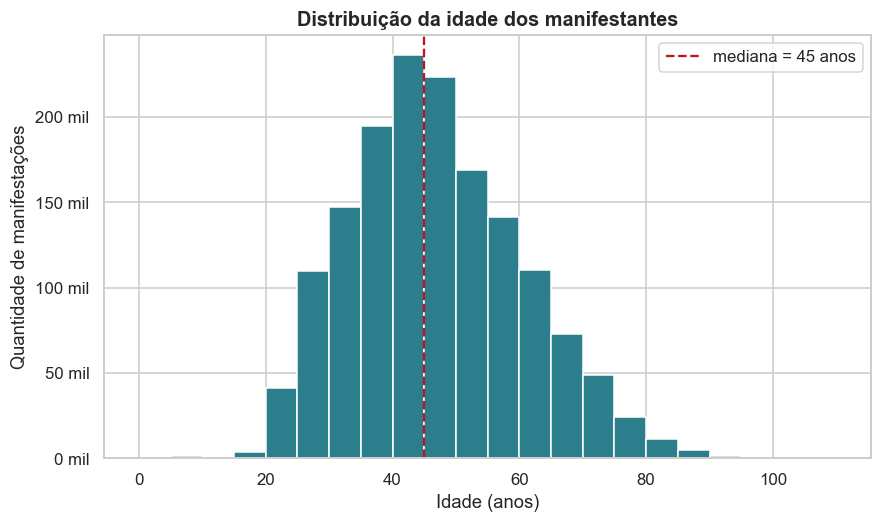

n = 1,544,437 idades válidas | média 46.5 | mediana 45


In [15]:
idades = df["Idade"].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(idades, bins=range(0, 111, 5), color=PALETA[5], edgecolor="white")
ax.axvline(idades.median(), color=VERMELHO, ls="--", lw=1.5,
           label=f"mediana = {idades.median():.0f} anos")
ax.set_title("Distribuição da idade dos manifestantes")
ax.set_xlabel("Idade (anos)"); ax.set_ylabel("Quantidade de manifestações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} mil"))
ax.legend()
salvar(fig, "fig04_hist_idade.png"); plt.show()
print(f"n = {len(idades):,} idades válidas | média {idades.mean():.1f} | mediana {idades.median():.0f}")

**Interpretação:** quem aciona a Ouvidoria é majoritariamente **adulto de meia-idade**: a idade
mediana é **45 anos** e a distribuição se concentra entre ~35 e ~56 anos. Jovens (<25) e idosos (>70)
participam pouco — possivelmente por menor familiaridade com o canal digital ou menor necessidade de
acionar serviços públicos. (Base: ~1,54 milhão de idades válidas; ~28% das manifestações não informam idade.)

### Gráfico 5 — Idade por tipo de manifestação (boxplot)

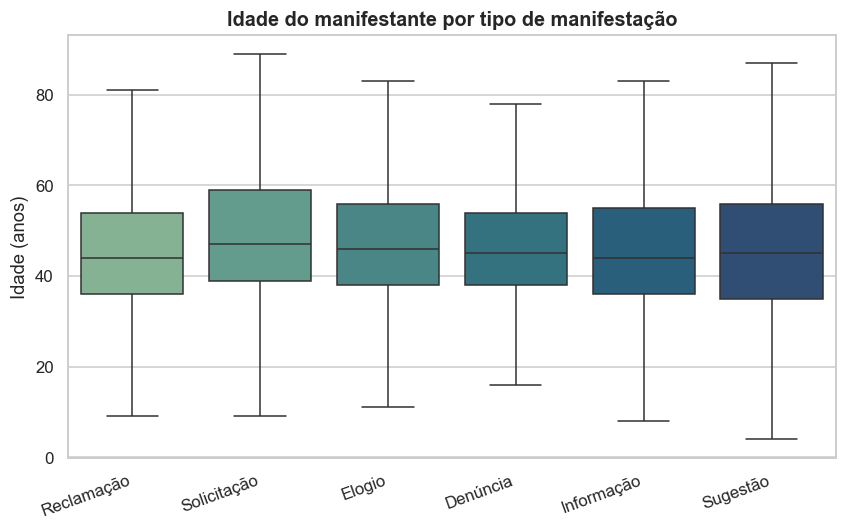

In [16]:
ordem_cls = df["Classificacao"].value_counts().index.tolist()
sub = df[df["Classificacao"].isin(ordem_cls) & df["Idade"].notna()]
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=sub, x="Classificacao", y="Idade", order=ordem_cls,
            showfliers=False, palette="crest", ax=ax)
ax.set_title("Idade do manifestante por tipo de manifestação")
ax.set_xlabel(""); ax.set_ylabel("Idade (anos)")
plt.xticks(rotation=20, ha="right")
salvar(fig, "fig05_box_idade_classificacao.png"); plt.show()

**Interpretação:** o perfil etário é **estável entre os tipos** de manifestação — todas as medianas
ficam por volta de 45 anos. Há uma leve tendência de **solicitações** virem de pessoas um pouco mais
velhas (mediana ~48) e **reclamações** de pessoas um pouco mais novas, mas a sobreposição das caixas
mostra que **idade não diferencia muito** o tipo de manifestação: pessoas de todas as idades reclamam,
solicitam e denunciam de forma parecida.

### Gráfico 6 — Manifestações por Região Administrativa (top 12)

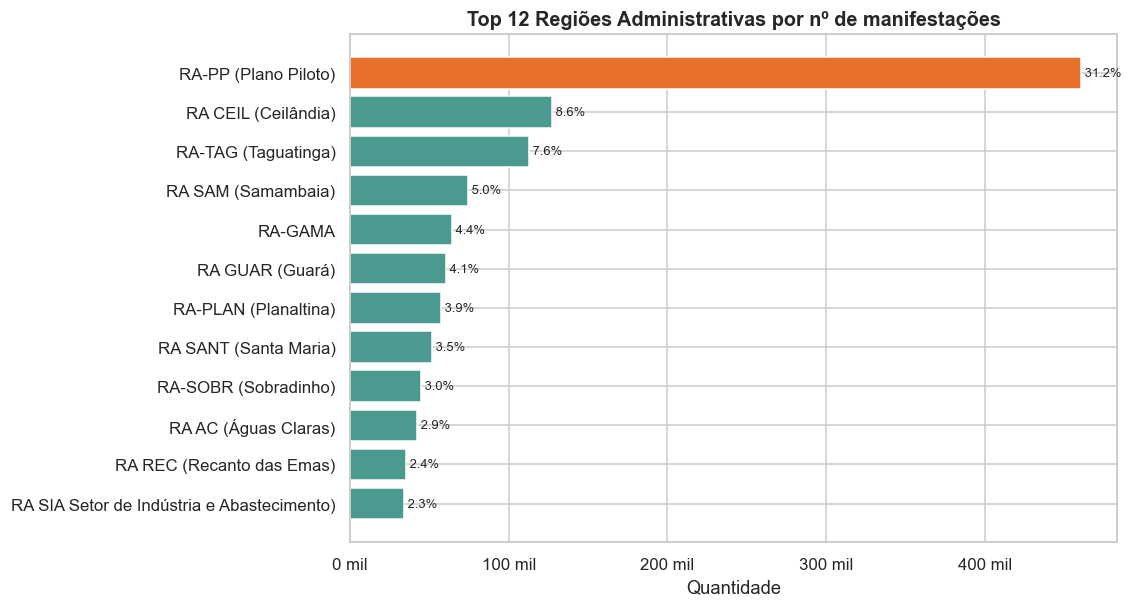

Manifestações com RA informada: 1,475,926 (68.5% do total)


In [17]:
ra = df["RA"].value_counts().head(12).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
cores = [LARANJA if "Plano Piloto" in i else PALETA[3] for i in ra.index]
ax.barh(ra.index, ra.values, color=cores)
ax.set_title("Top 12 Regiões Administrativas por nº de manifestações")
ax.set_xlabel("Quantidade"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} mil"))
base_ra = df["RA"].notna().sum()
for i, v in enumerate(ra.values):
    ax.text(v, i, f" {v/base_ra*100:.1f}%", va="center", fontsize=8.5)
salvar(fig, "fig06_regioes.png"); plt.show()
print(f"Manifestações com RA informada: {base_ra:,} ({base_ra/len(df)*100:.1f}% do total)")

**Interpretação:** há forte **concentração territorial**. Entre as manifestações que **informam a região**,
o **Plano Piloto** sozinho responde por mais de **31%** (≈ 21% do total geral) — muito acima de regiões
bem mais populosas, como Ceilândia (~9%) e Taguatinga (~8%). Isso sugere **acesso desigual** ao canal
(e/ou maior demanda da região central). Vale lembrar que **~31% das manifestações não informam a RA**,
o que limita a leitura geográfica e é, em si, um problema de qualidade do dado.

### Gráfico 7 — Desfecho das manifestações (situação)

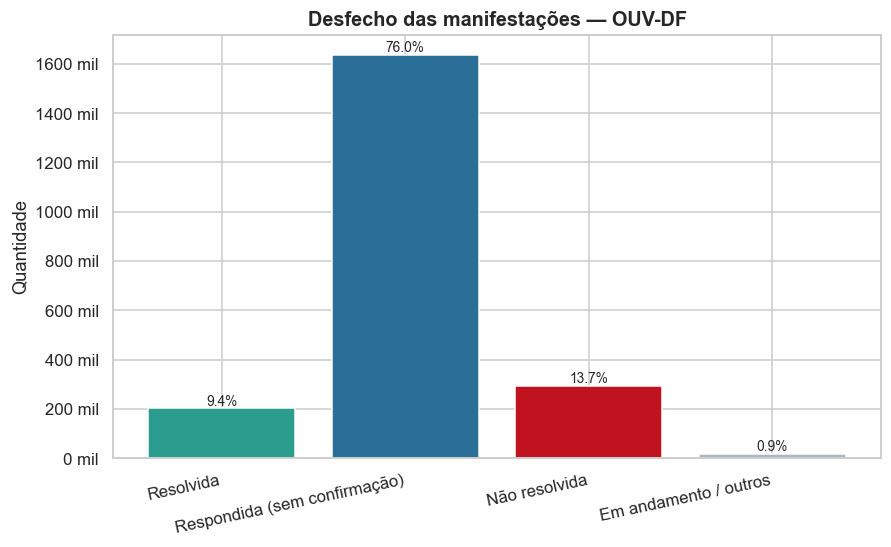

In [18]:
def agrupa_situacao(s):
    if pd.isna(s): return "Outros"
    if "Resolvida" in s and "Não" not in s: return "Resolvida"
    if s == "Respondida": return "Respondida (sem confirmação)"
    if "Não" in s: return "Não resolvida"
    return "Em andamento / outros"

desfecho = df["Situacao"].map(agrupa_situacao).value_counts()
ordem = ["Resolvida","Respondida (sem confirmação)","Não resolvida","Em andamento / outros"]
desfecho = desfecho.reindex([o for o in ordem if o in desfecho.index])
cores = [VERDE, AZUL, VERMELHO, "#adb5bd"]
fig, ax = plt.subplots(figsize=(9, 5))
b = ax.bar(desfecho.index, desfecho.values, color=cores[:len(desfecho)])
ax.set_title("Desfecho das manifestações — OUV-DF")
ax.set_xlabel(""); ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} mil"))
plt.xticks(rotation=12, ha="right")
tot = desfecho.sum()
for bi, v in zip(b, desfecho.values):
    ax.text(bi.get_x()+bi.get_width()/2, v, f"{v/tot*100:.1f}%", ha="center", va="bottom", fontsize=9)
salvar(fig, "fig07_desfecho.png"); plt.show()

**Interpretação:** aparece aqui o achado mais delicado. A grande maioria (~**76%**) fica como
**“Respondida”** — o órgão deu uma resposta —, mas só cerca de **9%** são efetivamente marcadas como
**“Resolvida”**, contra ~14% explicitamente **“Não resolvida”**. Ou seja, **responder não é o mesmo que
resolver**: existe um *gap* importante entre o atendimento formal e a solução concreta do problema do
cidadão. (A categoria “Respondida” depende de confirmação posterior do cidadão, o que ajuda a explicar
o número — mas o contraste resolvida × não resolvida continua desfavorável.)

### Gráfico 8 — Volume × resolução por Região Administrativa (dispersão)

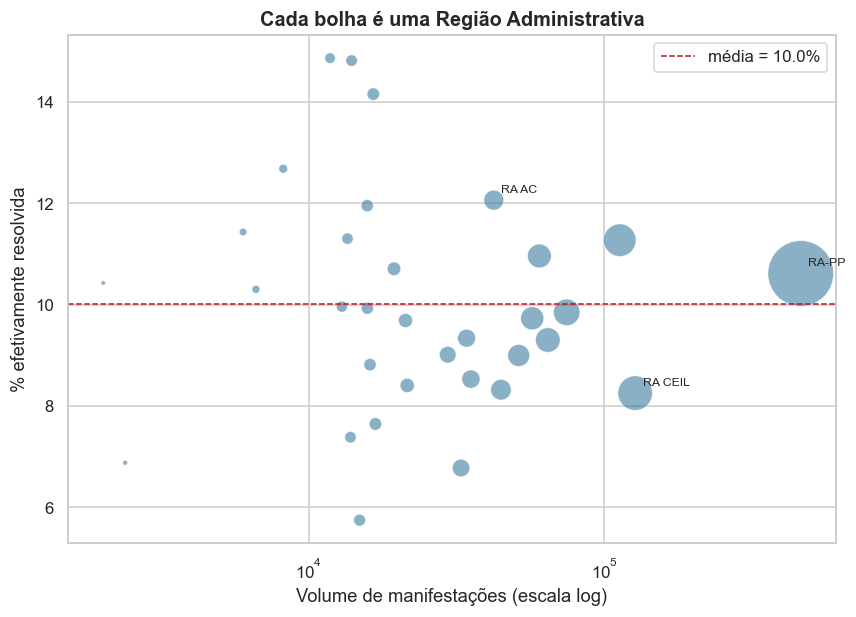

In [19]:
df["resolvida"] = df["Situacao"].isin(["Resolvida","Resolvida após resposta complementar"])
g = (df[df["RA"].notna()]
     .groupby("RA")
     .agg(volume=("RA","size"), pct_resolvida=("resolvida","mean"))
     .query("volume >= 1000"))
g["pct_resolvida"] *= 100

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(g["volume"], g["pct_resolvida"], s=g["volume"]/250,
           alpha=0.55, color=AZUL, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_title("Cada bolha é uma Região Administrativa")
ax.set_xlabel("Volume de manifestações (escala log)")
ax.set_ylabel("% efetivamente resolvida")
ax.axhline(g["pct_resolvida"].mean(), color=VERMELHO, ls="--", lw=1,
           label=f"média = {g['pct_resolvida'].mean():.1f}%")
for nome in ["RA-PP (Plano Piloto)", "RA CEIL (Ceilândia)", "RA AC (Águas Claras)"]:
    if nome in g.index:
        ax.annotate(nome.split("(")[0].strip(), (g.loc[nome,"volume"], g.loc[nome,"pct_resolvida"]),
                    fontsize=8, xytext=(5,5), textcoords="offset points")
ax.legend()
salvar(fig, "fig08_scatter_ra.png"); plt.show()

**Interpretação:** não há relação positiva entre **demandar muito** e **ser mais atendido**. As taxas de
resolução efetiva ficam todas em uma faixa estreita e **baixa (~8% a 12%)**, independentemente do volume
da região — inclusive o Plano Piloto, que mais manifesta, resolve em torno da média. A baixa resolução
é **sistêmica**, não um problema de uma região específica.

---
# 4. Conclusões

**1. A Ouvidoria do DF é, na prática, um grande canal de reclamação.**
~67% das 2,15 milhões de manifestações são reclamações e apenas ~5% são elogios (Gráfico 1). O cidadão
usa a OUV-DF para **cobrar** serviços, o que torna o sistema um termômetro direto da insatisfação com o
serviço público.

**2. A demanda é dominada por serviços essenciais e de zeladoria urbana.**
Saúde, Transporte/Mobilidade, Zeladoria e Habitação/Urbanismo somam ~65% dos temas (Gráfico 2), e os
assuntos campeões são concretos e cotidianos — vagas de consulta/CRAS, passe livre estudantil,
tapa-buraco e iluminação pública. É aí que o GDF deveria priorizar melhorias.

**3. Responder não é resolver: a resolução efetiva é baixa.**
76% das manifestações ficam como “Respondida”, mas só ~9% como “Resolvida”, contra ~14% “Não resolvida”
(Gráfico 7). Existe um *gap* claro entre o atendimento formal e a solução do problema — e ele é
**sistêmico**, sem variar muito entre regiões (Gráfico 8).

**4. O acesso é desigual no território e o perfil de quem usa é restrito.**
O Plano Piloto concentra ~31% das manifestações que informam a região (≈ 21% do total), muito acima de
regiões bem mais populosas (Gráfico 6), e ~31% dos registros sequer informam a RA. Quem se manifesta é predominantemente
**adulto de meia-idade** (mediana de 45 anos, Gráfico 4) e mais **feminino** (seção 2.5). Ampliar o alcance do
canal para regiões periféricas e faixas etárias sub-representadas é um caminho de melhoria.

---
### Limitações e honestidade da análise
- ~26–31% de campos opcionais ausentes (idade, sexo, bairro, região) — tratados por filtragem, não por exclusão de linhas.
- “Respondida” depende de confirmação posterior do cidadão; parte do baixo índice de “Resolvida” pode refletir não-confirmação, não apenas não-solução.
- 2016 e 2025 são anos parciais e não devem ser comparados diretamente aos anos completos.
- A análise é **descritiva** (o que aconteceu), não causal.